<a href="https://colab.research.google.com/github/andiorandrea/PGP-UT-assignments/blob/main/INN_ReneWind_Main_Project_FullCode_Notebook_Taylor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [5]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location


from sklearn import metrics
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    confusion_matrix, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestClassifier, BaggingClassifier
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [6]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

# Load the data
train_data = pd.read_csv('/content/Train.csv')
test_data = pd.read_csv('/content/Test.csv')

# Display first few rows
print("First 5 rows of training data:")
display(train_data.head())

df = train_data.copy()
df_test = test_data.copy()

First 5 rows of training data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


# **Data Overview**

In [7]:

# Shape of dataset
print("Shape of training data:", df.shape)
print("Shape of test data:", df_test.shape)

# View the first 5 rows of the training and test data set
print("\nFirst 5 rows of training and test data:")
display(df.head())
display(df_test.head())

# Data types and information
print("\nData Types and Information:")
df.info()
df_test.info()

# Check for missing values
print("\nMissing Values and Duplicates:")
display(df.isnull().sum())
display(df_test.isnull().sum())

# Check for duplicates
display(df.duplicated().sum())
display(df_test.duplicated().sum())

# Statistical Summary
print("\nStatistical Summary:")
df.describe()
df_test.describe()

Shape of training data: (20000, 41)
Shape of test data: (5000, 41)

First 5 rows of training and test data:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0



Data Types and Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22   

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


0

0


Statistical Summary:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,...,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,...,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,...,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,...,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,...,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,...,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,...,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000


This analysis confirms that the data has loaded properly, the columns corrrespond to the various sensors, the last column corresponds to the target variable to determine if the sensor is considered a failure and each row corresponds to a generator.

The training set has 20K rows and 41 columns, the test set has 5K rows and the same number of columns.

There are missing values in both datasets but there are no duplicated values.

The Target column has a mean close to 0, and the third quartile is close to 0 so we will assume that most of the sensors are not failing.

The mean and median of most variables are close together so we will assume a symmetrical distribution.

# **Exploratory Data Analysis**

## Univariate analysis

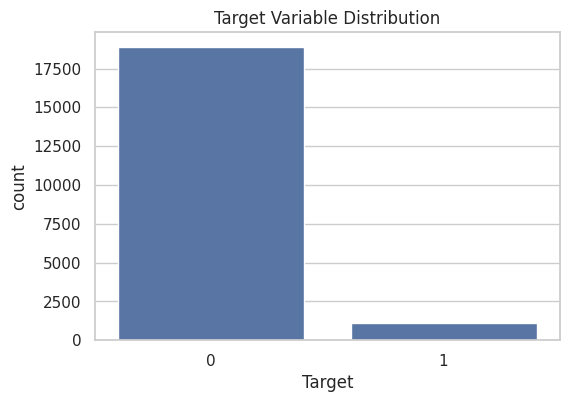

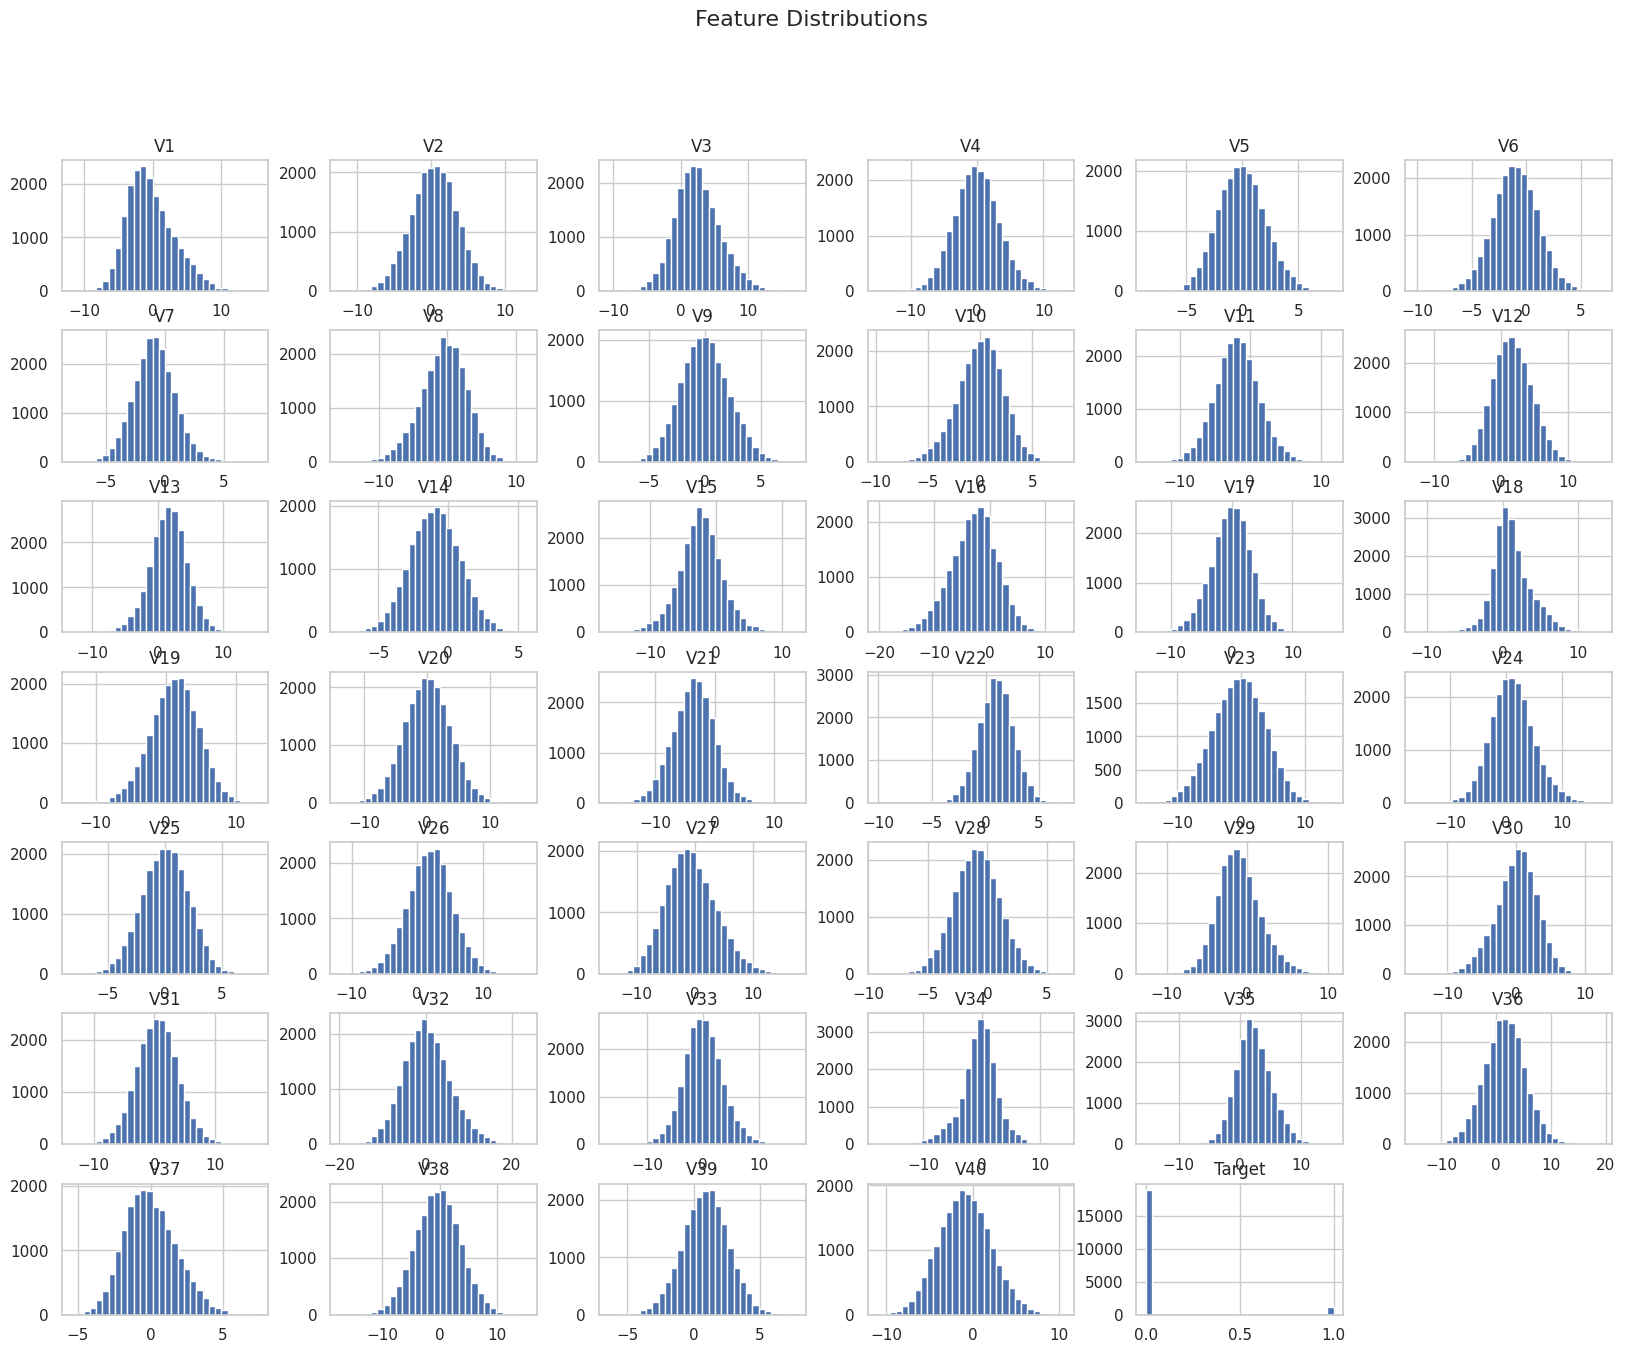

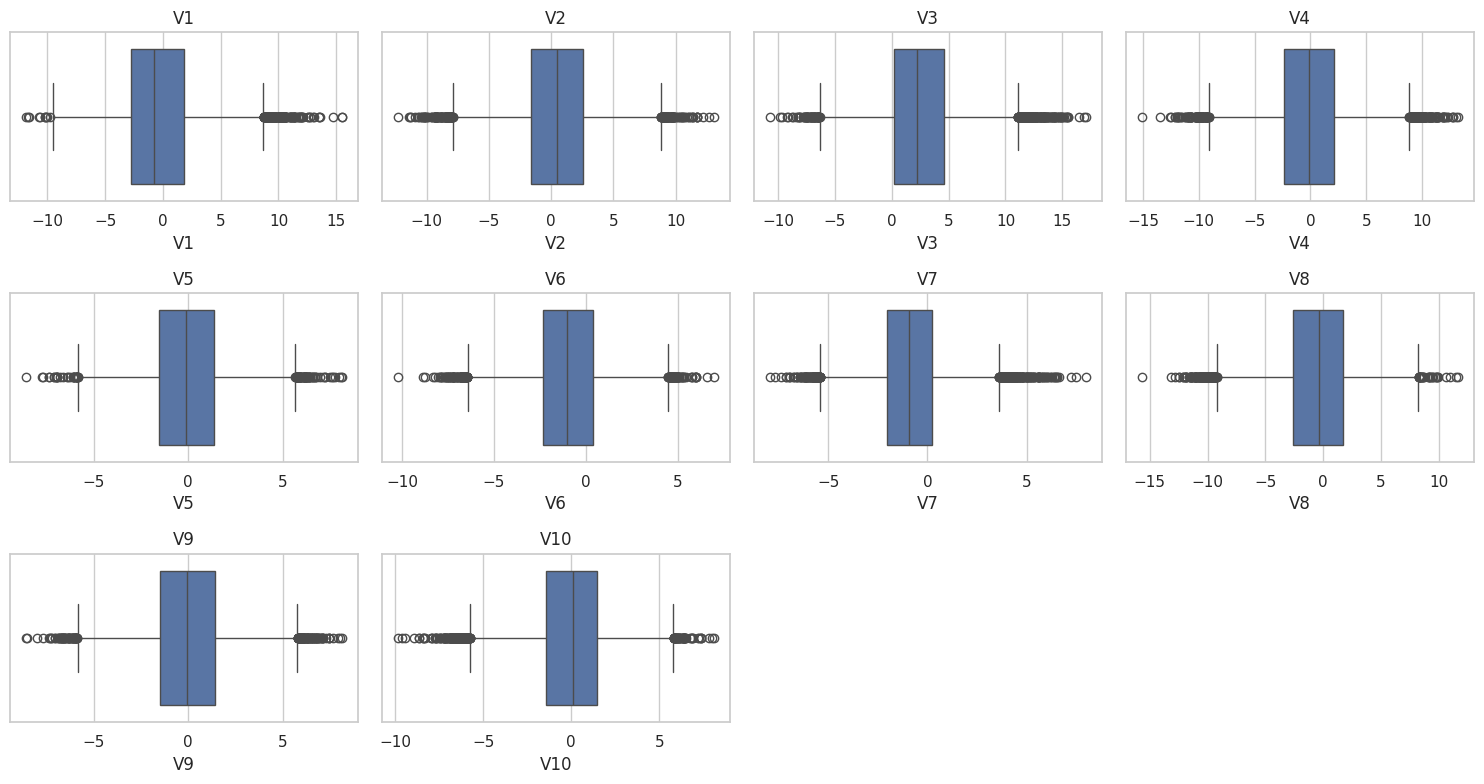

,count
Target,
0,18890
1,1110


In [8]:
sns.set(style="whitegrid")

# Target variable count plot
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title("Target Variable Distribution")
plt.show()

# Histograms for numerical features
df.hist(figsize=(20,15), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# Boxplots to check outliers
sample_cols = df.columns[:10]

plt.figure(figsize=(15,8))
for i, col in enumerate(sample_cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Counts for target variable
df.Target.value_counts()

Attribute distribution is fairly symmetrical, there are positive and negative values for all predictor variables, and there are outliers on all of them. There are a few failures but most of the sensors detect that the generator is not failing.

## Bivariate Analysis

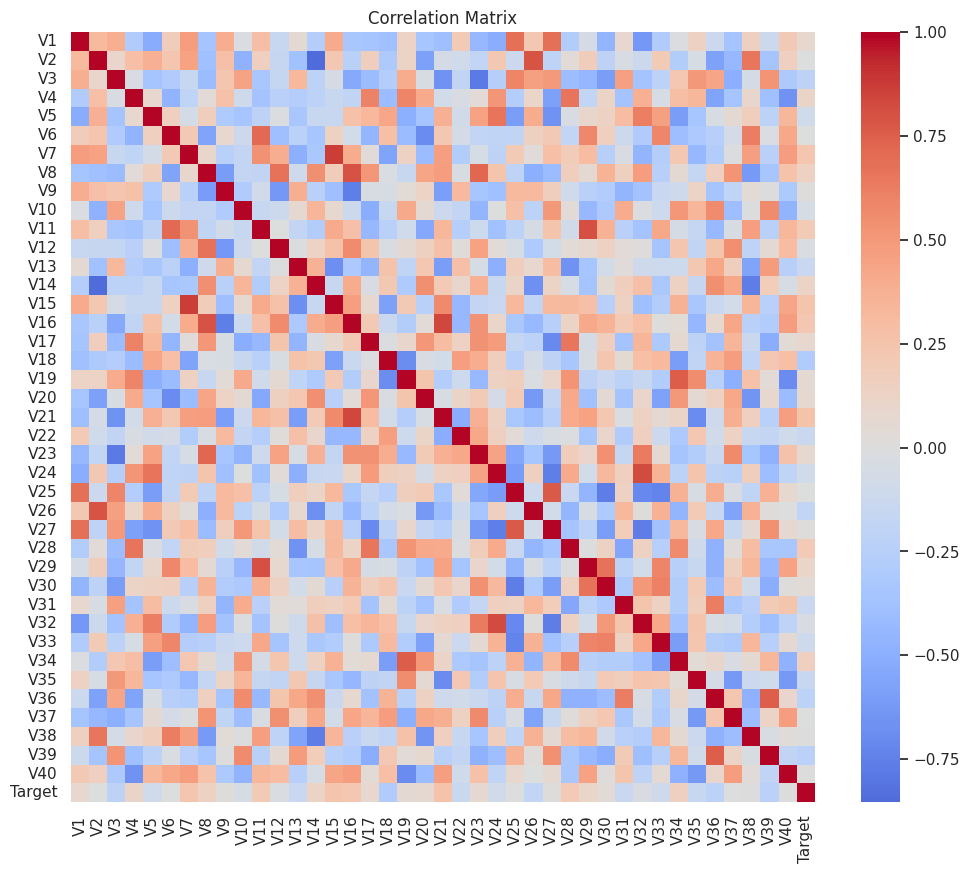

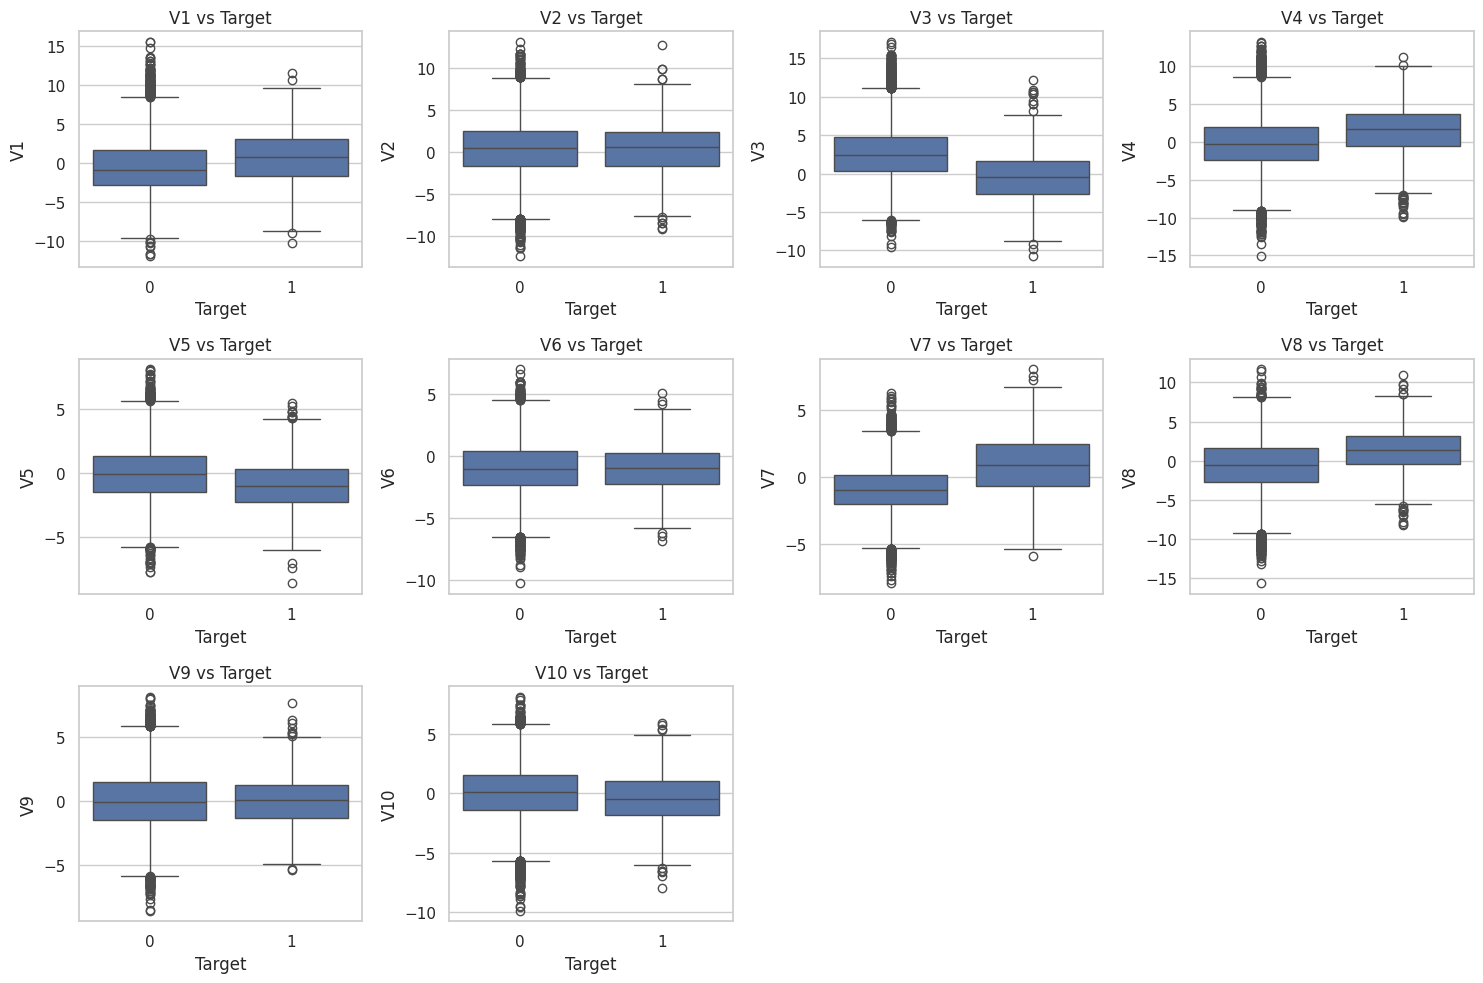

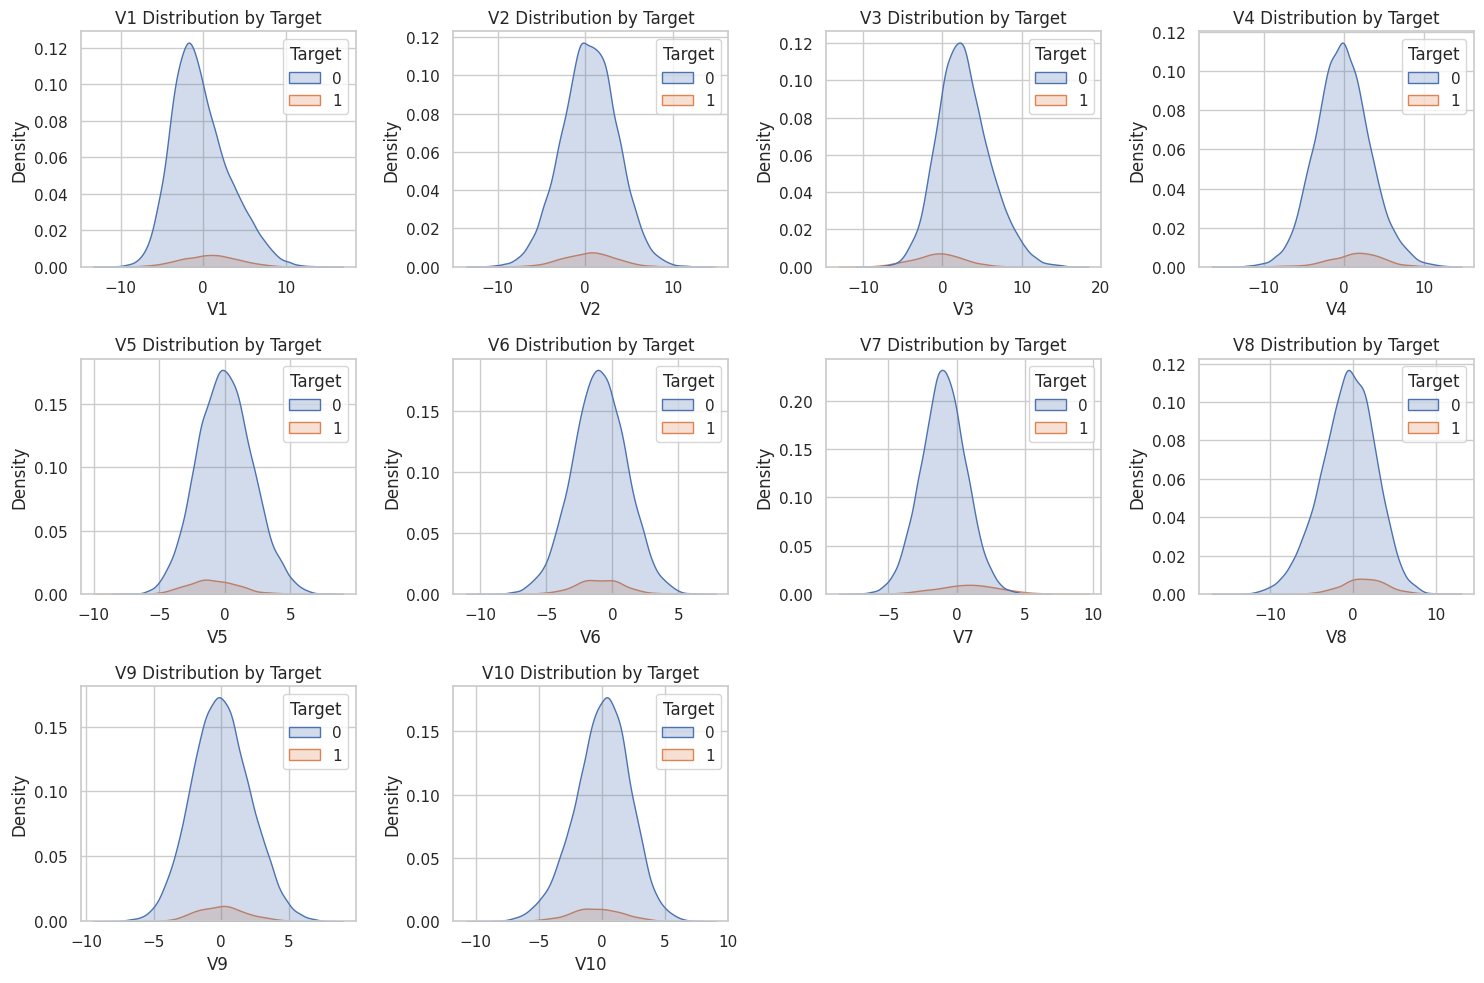

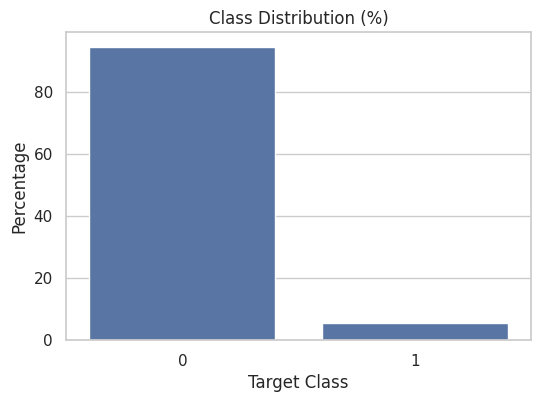

In [9]:
# Correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

# Feature vs Target
selected_cols = df.columns[:10]

plt.figure(figsize=(15,10))
for i, col in enumerate(selected_cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(x='Target', y=col, data=df)
    plt.title(f"{col} vs Target")
plt.tight_layout()
plt.show()

# Distribution comparison (KDE plots)
plt.figure(figsize=(15,10))
for i, col in enumerate(selected_cols):
    plt.subplot(3,4,i+1)
    sns.kdeplot(data=df, x=col, hue='Target', fill=True)
    plt.title(f"{col} Distribution by Target")
plt.tight_layout()
plt.show()

# Class distribution in percentage
class_dist = df['Target'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=class_dist.index, y=class_dist.values)
plt.title("Class Distribution (%)")
plt.ylabel("Percentage")
plt.xlabel("Target Class")
plt.show()


# **Data Preprocessing**

In [10]:
# Defining X (independent) and y (dependent) variables for train set
X = df.drop(['Target'], axis=1)
y = df['Target']

# Splitting train dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)

# Checking the number of rows and columns in training and validation sets
print(X_train.shape, X_val.shape)

# Defining X (independent) and y (dependent) variables for test set
X_test = df_test.drop(['Target'], axis=1)
y_test = df_test['Target']

# Checking the number of rows and columns in test set
print(X_test.shape)

# Use median values to resolve missing values in V1 and V2
imputer = SimpleImputer(strategy='median')

# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# fit and transform the imputer on test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

# Checking that there are no missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

(15000, 40) (5000, 40)
(5000, 40)
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18  

Split the data to avoid data leaks, applied feature engineering, prepared the data for modeling, applied missing value treatment and confirmed there are no missing values in the dataset.

# **Model Building**

## Model Evaluation Criterion

In [11]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # Predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

In [12]:
# Defining a function to display confusion matrix
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

We will be analyzing the model performance based on the true positives - failures correctly predicted by the model, the false negatives - the real failures that aren't detected by the model, and the false positives = where there is a failure detected that isn't real. We'll optimize for the highest recall score in order to minimize false negative and will definte a function to output the metrics to show a confusion metric so that we don't have to repeat the same code for every model.

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer


Cross-Validation performance on training dataset:

Decision Tree: 0.6982829521679532
Bagging: 0.7210807301060529
Random forest: 0.7235192266070268
Logistic Regression: 0.4927566553639709
GBM: 0.7066661857008874
Adaboost: 0.6309140754635308
Xgboost: 0.801644902965154

Validation Performance:

Decision Tree: 0.7050359712230215
Bagging: 0.7302158273381295
Random forest: 0.7266187050359713
Logistic Regression: 0.48201438848920863
GBM: 0.7230215827338129
Adaboost: 0.6762589928057554
Xgboost: 0.841726618705036


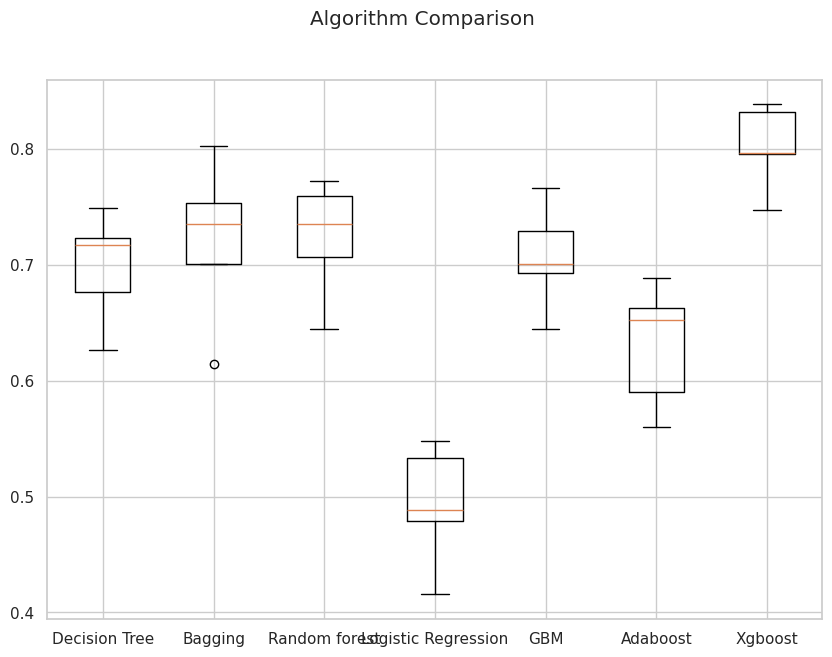

In [13]:
models = []  # Model list

# Appending Models into the list
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))

results = []
names = []


# Get the mean cross validated score for all models
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

# Plotting boxplots for CV scores of all models
fig = plt.figure(figsize=(10,7))

fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

XGBoost and Bagging have the highest cross validation performance scores.

# **Model Performance Improvement**

## OverSampled Data

Before Over Sampling, counts of label 'Yes' : 832
Before Over Sampling, counts of label 'No' : 14168 

After Over Sampling, counts of label 'Yes': 14168
After Over Sampling, counts of label 'No': 14168 

After Over Sampling, the shape of X_train: (28336, 40)
After Over Sampling, the shape of y_train: (28336,) 


Cross-Validation performance on training dataset:

Decision Tree: 0.9720494245534969
Bagging: 0.9762141471581656
Random forest: 0.9839075260047615
Logistic Regression: 0.883963699328486
GBM: 0.9256068151319724
Adaboost: 0.8978689011775473
Xgboost: 0.9891305241357218

Validation Performance:

Decision Tree: 0.7769784172661871
Bagging: 0.8345323741007195
Random forest: 0.8489208633093526
Logistic Regression: 0.8489208633093526
GBM: 0.8776978417266187
Adaboost: 0.8561151079136691
Xgboost: 0.8669064748201439


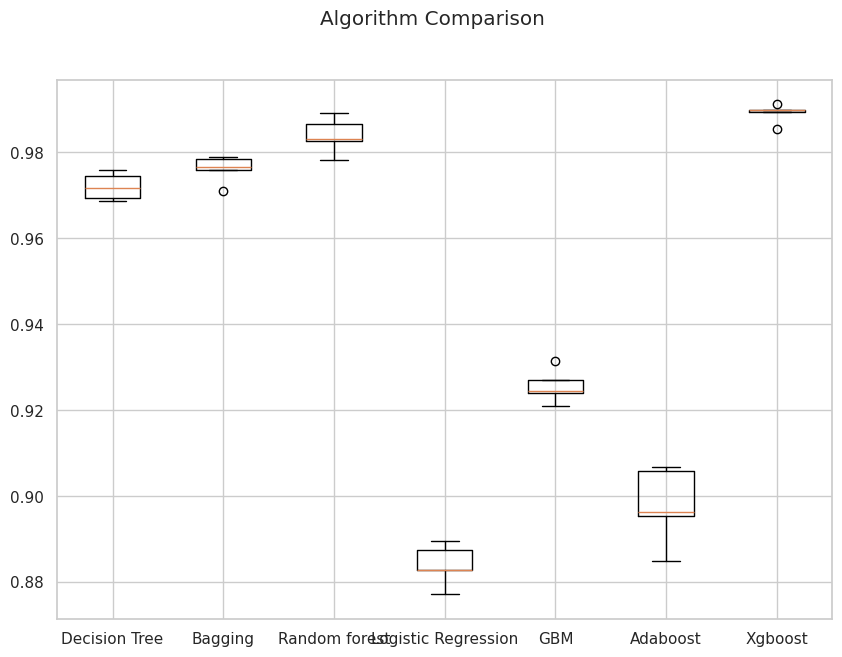

In [14]:
# OverSampled Data using SMOTE
print("Before Over Sampling, counts of label 'Yes' : {}".format(sum(y_train == 1)))
print("Before Over Sampling, counts of label 'No' : {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After Over Sampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Over Sampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Over Sampling, the shape of X_train: {}".format(X_train_over.shape))
print("After Over Sampling, the shape of y_train: {} \n".format(y_train_over.shape))

models_over = []  # Empty list to store all the models

# Appending models into the list
models_over.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models_over.append(("Bagging", BaggingClassifier(random_state=1)))
models_over.append(("Random forest", RandomForestClassifier(random_state=1)))
models_over.append(("Logistic Regression", LogisticRegression(random_state=1)))
models_over.append(("GBM", GradientBoostingClassifier(random_state=1)))
models_over.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models_over.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))

results_over = []  # CV scores
names_over = []  # Model names

# Mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models_over:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results_over.append(cv_result)
    names_over.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

# Boxplots for CV scores of all models
fig = plt.figure(figsize=(10,7))

fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)

plt.boxplot(results_over)
ax.set_xticklabels(names_over)

plt.show()

##UnderSampled Data

Before Under Sampling, counts of label 'Yes' : 832
Before Under Sampling, counts of label 'No' : 14168 

After Under Sampling, counts of label 'Yes': 832
After Under Sampling, counts of label 'No': 832 

After Under Sampling, the shape of X_train: (1664, 40)
After Under Sampling, the shape of y_train: (1664,) 


Cross-Validation performance on training dataset:

Decision Tree: 0.8617776495202367
Bagging: 0.8641945025611427
Random forest: 0.9038669648654498
Logistic Regression: 0.8726138085275232
GBM: 0.8990621167303946
Adaboost: 0.8666113556020489
Xgboost: 0.9014717552846114

Validation Performance:

Decision Tree: 0.841726618705036
Bagging: 0.8705035971223022
Random forest: 0.8920863309352518
Logistic Regression: 0.8525179856115108
GBM: 0.8884892086330936
Adaboost: 0.8489208633093526
Xgboost: 0.89568345323741


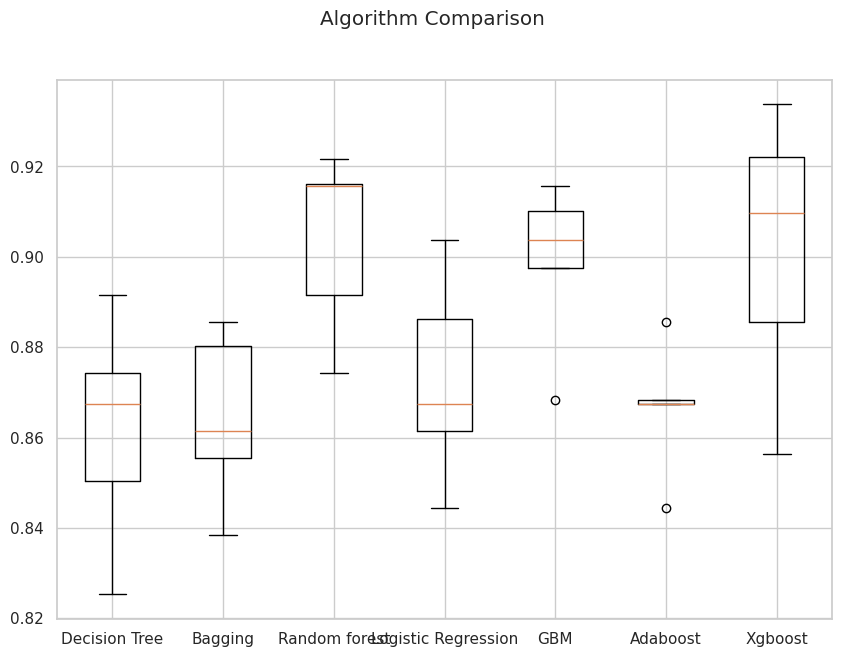

In [15]:
# Models with Under Sampled data

print("Before Under Sampling, counts of label 'Yes' : {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No' : {} \n".format(sum(y_train == 0)))

# Random Under Sampler
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_under == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_under == 0)))

print("After Under Sampling, the shape of X_train: {}".format(X_train_under.shape))
print("After Under Sampling, the shape of y_train: {} \n".format(y_train_under.shape))


models_under = []  # Empty list to store all the models

# Appending models into the list
models_under.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models_under.append(("Bagging", BaggingClassifier(random_state=1)))
models_under.append(("Random forest", RandomForestClassifier(random_state=1)))
models_under.append(("Logistic Regression", LogisticRegression(random_state=1)))
models_under.append(("GBM", GradientBoostingClassifier(random_state=1)))
models_under.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models_under.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))

results_under = []  # CV scores
names_under = []  # Model Names

# Mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models_under:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_under, y=y_train_under, scoring=scorer, cv=kfold
    )
    results_under.append(cv_result)
    names_under.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models_under:
    model.fit(X_train_under, y_train_under)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

# Boxplots for CV scores of all models
fig = plt.figure(figsize=(10,7))

fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)

plt.boxplot(results_under)
ax.set_xticklabels(names_under)

plt.show()

## Hyperparameter Tuning

In [16]:
#Hyperparameter Tuning

Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": np.arange(100,150,25),
              "learning_rate": [0.2, 0.05, 1],
               "subsample":[0.5,0.7],
               "max_features":[0.5,0.7] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 1} with CV score=0.9723322092856124:


In [17]:
# Gradient Boost using over sampled data
tuned_gbm_random = GradientBoostingClassifier(
    max_features=0.5,
    random_state=1,
    learning_rate=0.2,
    n_estimators=125,
    subsample=0.7
)

tuned_gbm_random.fit(X_train_over, y_train_over)

# Checking metrics for train set with random search
gbm_random_train = model_performance_classification_sklearn(tuned_gbm_random, X_train_over, y_train_over)
gbm_random_train

# Checking metrics for validation set with random search
gbm_random_val = model_performance_classification_sklearn(tuned_gbm_random, X_val, y_val)
gbm_random_val

,Accuracy,Recall,Precision,F1
0,0.9746,0.877698,0.724036,0.793496


In [26]:
# AdaBoost with over sampled data

# Defining model
abm_random = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=abm_random, param_distributions=param_grid, n_jobs = -1, n_iter=6, scoring=scorer, cv=5, random_state=1)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

/root/.local/lib/python3.12/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Best parameters are {'n_estimators': 200, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.9714853746337214:


In [27]:

# Creating a new pipeline with best parameters
tuned_abm_random = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.2,
    random_state=1,
    base_estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)

# Fit the model on training data
tuned_abm_random.fit(X_train_over, y_train_over)

# Calculating metrics on train set with random search
abm_random_train= model_performance_classification_sklearn(tuned_abm_random, X_train_over, y_train_over)
abm_random_train

# Looking at the metrics on validation set
abm_random_val= model_performance_classification_sklearn(tuned_abm_random, X_val, y_val)
abm_random_val

/root/.local/lib/python3.12/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


,Accuracy,Recall,Precision,F1
0,0.9792,0.852518,0.79,0.820069


In [28]:
# Random Forest with under sampled data

# Defining model
rf_random = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=rf_random, param_distributions=param_grid, scoring=scorer, cv=5, n_jobs = -1, n_iter=50, random_state=1)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_under, y_train_under)

print("Best Parameters:{} \nScore: {}".format(randomized_cv.best_params_, randomized_cv.best_score_))


# Creating a new pipeline with best parameters
tuned_rf_random = RandomForestClassifier(
    n_estimators=300,
    random_state=1,
    max_features='sqrt',
    max_samples=0.5,
    min_samples_leaf=2
)

# Fit the model on training data
tuned_rf_random.fit(X_train_under, y_train_under)

# Calculating metrics on train set
rf_random_train= model_performance_classification_sklearn(tuned_rf_random, X_train_under, y_train_under)
rf_random_train

# Calculating metrics on validation set
rf_random_val= model_performance_classification_sklearn(tuned_rf_random, X_val, y_val)
rf_random_val

/root/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
125 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "/root/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/root/.local/lib/python3.12/site-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/root/.local/lib/python3.12/site-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/root/.local/lib/python3.12/site-packages/sk

Best Parameters:{'n_estimators': 300, 'min_samples_leaf': 2, 'max_samples': 0.5, 'max_features': 'sqrt'} 
Score: 0.8990116153235697


,Accuracy,Recall,Precision,F1
0,0.9376,0.884892,0.467681,0.61194


In [29]:
# XGBoost on under sampled Data

# Defining model
xgb_random = XGBClassifier(random_state=1,eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
random_cv = RandomizedSearchCV(estimator=xgb_random, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

# Fitting parameters in RandomizedSearchCV
random_cv.fit(X_train_under, y_train_under)

print("Best parameters are {} with CV score={}:" .format(random_cv.best_params_, random_cv.best_score_))


# Building model with best parameters
tuned_xgb_random = XGBClassifier(
    random_state=1,
    n_estimators=200,
    scale_pos_weight=10,
    subsample=0.9,
    learning_rate=0.1,
    gamma=5,
    eval_metric="logloss"
)

# Fit the model on training data
tuned_xgb_random.fit(X_train_under, y_train_under)

# Calculating metrics on train set
xgb_random_train= model_performance_classification_sklearn(tuned_xgb_random, X_train_under, y_train_under)
xgb_random_train

# Calculating metrics on validation set
xgb_random_val= model_performance_classification_sklearn(tuned_xgb_random, X_val, y_val)
xgb_random_val



Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.1, 'gamma': 5} with CV score=0.9290599523843879:


,Accuracy,Recall,Precision,F1
0,0.8324,0.920863,0.238806,0.379259


In [30]:
# XGBoost with over sampled data

# Defining model
xgb_random1 = XGBClassifier(random_state=1,eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
random_cv1 = RandomizedSearchCV(estimator=xgb_random, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

# Fitting parameters in RandomizedSearchCV
random_cv1.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(random_cv1.best_params_, random_cv1.best_score_))

# Building model with best parameters
tuned_xgb_random1 = XGBClassifier(
    random_state=1,
    n_estimators=150,
    scale_pos_weight=10,
    subsample=0.9,
    learning_rate=0.1,
    gamma=0,
    eval_metric="logloss",
)

# Fit the model on training data
tuned_xgb_random1.fit(X_train_over, y_train_over)

# Calculating metrics on train set
xgb_random1_train= model_performance_classification_sklearn(tuned_xgb_random1, X_train_over, y_train_over)
xgb_random1_train

# Calculating metrics on validation set
xgb_random1_val= model_performance_classification_sklearn(tuned_xgb_random1, X_val, y_val)
xgb_random1_val

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 150, 'learning_rate': 0.1, 'gamma': 0} with CV score=0.9960475154078072:


,Accuracy,Recall,Precision,F1
0,0.967,0.892086,0.64752,0.750378


Oversampling Data results:
*  XGBoost gives the best cross validated recall
*  Performance decreases in validation sets but overall perform better than the models with the original data

Undersampling Data results:
*  Random Forest gives the best cross validated recall

Hyperparameter Tuning
*  XGBoost on undersampled data is the best performing model so far with 92% failure prediction

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [31]:
# Training performance comparison
models_train_comp_df = pd.concat(
    [
        gbm_random_train.T,
        abm_random_train.T,
        rf_random_train.T,
        xgb_random_train.T,
        xgb_random1_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting Tuned",
    "AdaBoost Tuned",
    "Random Forest Tuned",
    "XGBoost Undersampled Tuned",
    "XGBoost Oversampled Tuned"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting Tuned,AdaBoost Tuned,Random Forest Tuned,XGBoost Undersampled Tuned,XGBoost Oversampled Tuned
Accuracy,0.973320,0.991777,0.960938,0.978966,0.993718
Recall,0.959839,0.988283,0.932692,1.000000,1.000000
Precision,0.986436,0.995238,0.988535,0.959631,0.987592
F1,0.972956,0.991748,0.959802,0.979400,0.993757


In [32]:
# Validation performance comparison
models_val_comp_df = pd.concat(
    [
        gbm_random_val.T,
        abm_random_val.T,
        rf_random_val.T,
        xgb_random_val.T,
        xgb_random1_val.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting Tuned",
    "AdaBoost Tuned",
    "Random Forest Tuned",
    "XGBoost Undersampled Tuned",
    "XGBoost Oversampled Tuned"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting Tuned,AdaBoost Tuned,Random Forest Tuned,XGBoost Undersampled Tuned,XGBoost Oversampled Tuned
Accuracy,0.974600,0.979200,0.937600,0.832400,0.967000
Recall,0.877698,0.852518,0.884892,0.920863,0.892086
Precision,0.724036,0.790000,0.467681,0.238806,0.647520
F1,0.793496,0.820069,0.611940,0.379259,0.750378


Now, let's check the performance of the final model on the test set.

Test performance:


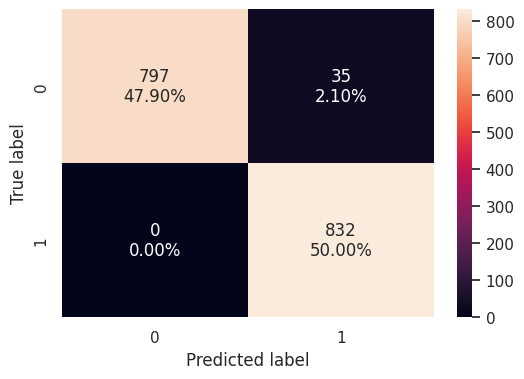

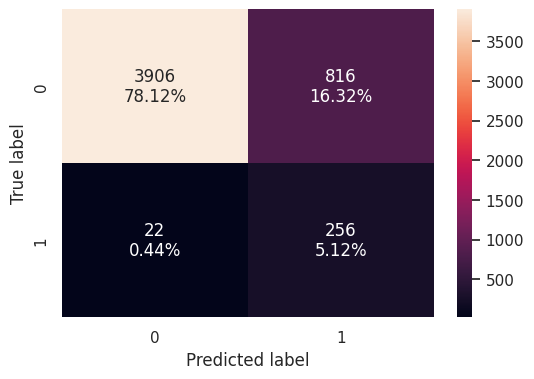

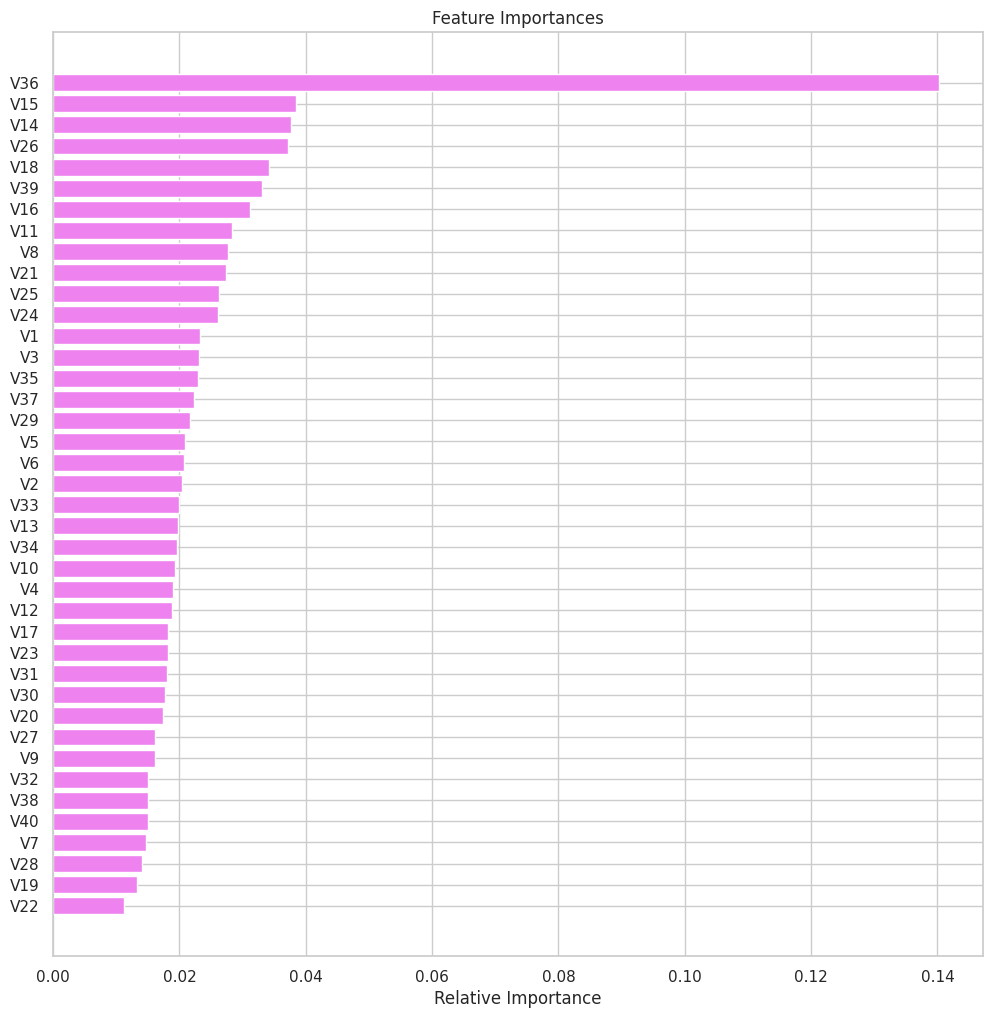

In [33]:
# Calculating metrics on test set (XGBoost with undersampled data)
xgb_random_test = model_performance_classification_sklearn(tuned_xgb_random, X_test, y_test)
print('Test performance:')
xgb_random_test

# Confusion matrix on training data
confusion_matrix_sklearn(tuned_xgb_random, X_train_under, y_train_under)

# Confusion matrix on validation data
confusion_matrix_sklearn(tuned_xgb_random, X_val, y_val)

# Feature importance

feature_names = X.columns
importances = tuned_xgb_random.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [34]:
# Create pipeline with best parameters
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
                        (
                            "XGB",
                            XGBClassifier(
                                random_state=1,
                                n_estimators=200,
                                scale_pos_weight=10,
                                subsample=0.9,
                                learning_rate=0.1,
                                gamma=5,
                                eval_metric="logloss"
                                )
                        )
    ]
)

# Split training dataset into dependent and independent variables
X_pipe = df.drop(['Target'], axis=1)
Y_pipe = df['Target']

# Split the test data into X and Y variables
X_test_pipe = df_test.drop(['Target'], axis=1)
Y_test_pipe = df_test['Target']

# Imput missing values before undersampling data
imputer = SimpleImputer(strategy='median')

# Fit and transform training data
X_pipe = imputer.fit_transform(X_pipe)

# Under sample data on training set
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_pipe_under, Y_pipe_under = rus.fit_resample(X_pipe, Y_pipe)

# Fitting the model on training data
pipe.fit(X_pipe_under, Y_pipe_under)

# Check performance on test set
pipe_test = model_performance_classification_sklearn(pipe, X_test_pipe, Y_test_pipe)
print("Final Model performance on Test Dataset:")
pipe_test

Final Model performance on Test Dataset:


/root/.local/lib/python3.12/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


,Accuracy,Recall,Precision,F1
0,0.838,0.890071,0.243689,0.382622


# **Actionable Insights and Recommendations**

*  Gradient Boosting and Random Search Tuning on the undersampled dataset performed best on the test set
*  The goal was to maximize recall to prevent replacing generators unnecessarily as this is more expensive than repairs or inpsections.
*  The most important sensors to consider will be V14, V15, and V26
*  The company will need to analyze whether the cost of extra failures is worth the extra cost of inspections
